# Time-Varying Break-Even Growth Rate

We estimate a time-varying-intercept version of the quarterly `U-Y` relation using IRISpie. The intercept is decomposed into a fixed component and a latent AR(1) deviation. We also include two COVID pulse dummies, for `2020 Q2` and `2020 Q3`, as fixed regressors in the measurement equation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import minimize

import irispie as ir
from irispie import ModelSource

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / 'data').exists() else CWD.parent
DATA_PATH = PROJECT_ROOT / 'data' / 'prepared' / 'analysis_dataset_quarterly.csv'
OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'time_varying_break_even_estimates.csv'

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

## Load Analysis Dataset

In [2]:
analysis_df = pd.read_csv(DATA_PATH, parse_dates=['date'])

state_df = analysis_df.loc[:, ['date', 'U', 'Y']].copy()
state_df['Y_lag1'] = state_df['Y'].shift(1)
state_df['Y_lag2'] = state_df['Y'].shift(2)
state_df['d2020q2'] = (state_df['date'] == pd.Timestamp('2020-04-01')).astype(float)
state_df['d2020q3'] = (state_df['date'] == pd.Timestamp('2020-07-01')).astype(float)
state_df = state_df.dropna().reset_index(drop=True)

state_df.head()

,date,U,Y,Y_lag1,Y_lag2,d2020q2,d2020q3
0,1992-07-01,0.459021,-0.726074,-0.085709,0.570575,0.0,0.0
1,1992-10-01,0.586024,-0.501668,-0.726074,-0.085709,0.0,0.0
2,1993-01-01,0.505504,-0.332376,-0.501668,-0.726074,0.0,0.0
3,1993-04-01,0.544153,0.917484,-0.332376,-0.501668,0.0,0.0
4,1993-07-01,0.405117,0.381316,0.917484,-0.332376,0.0,0.0


## Static Starting Values And State-Variance Calibration

We use the simple distributed-lag regression with the two COVID pulse dummies to initialize the fixed coefficients, including the fixed intercept. We calibrate the state innovation standard deviation to `0.1` times the OLS residual standard deviation, and estimate the remaining free parameters, including the AR(1) coefficient on the latent intercept deviation, by maximum likelihood inside the IRISpie Kalman filter.

In [3]:
X_start = sm.add_constant(state_df[['Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']])
ols_start = sm.OLS(state_df['U'], X_start).fit()

alpha_start = float(ols_start.params['const'])
sigma_ols = float(ols_start.resid.std(ddof=int(ols_start.df_model) + 1))
std_eta_fixed = 0.05 * sigma_ols

start_values = pd.DataFrame({
    'parameter': ['alpha', 'b0', 'b1', 'b2', 'g2', 'g3', 'sigma_ols', 'std_eta_fixed'],
    'value': [
        alpha_start,
        ols_start.params['Y'],
        ols_start.params['Y_lag1'],
        ols_start.params['Y_lag2'],
        ols_start.params['d2020q2'],
        ols_start.params['d2020q3'],
        sigma_ols,
        std_eta_fixed,
    ],
})
start_values

,parameter,value
0,alpha,0.125988
1,b0,-0.088044
2,b1,-0.109339
3,b2,-0.074553
4,g2,0.104101
5,g3,-0.370653
6,sigma_ols,0.157520
7,std_eta_fixed,0.007876


## IRISpie State-Space Setup

In [4]:
start_period = ir.qq(int(state_df.loc[0, 'date'].year), int((state_df.loc[0, 'date'].month - 1) / 3 + 1))
end_period = ir.qq(int(state_df.loc[state_df.index[-1], 'date'].year), int((state_df.loc[state_df.index[-1], 'date'].month - 1) / 3 + 1))
span = ir.periods_from_to(start_period, end_period)

input_db = ir.Databox.from_dict({
    'U_obs': ir.Series.from_start_and_array(start_period, state_df['U'].to_numpy()),
    'Y0': ir.Series.from_start_and_array(start_period, state_df['Y'].to_numpy()),
    'Y1': ir.Series.from_start_and_array(start_period, state_df['Y_lag1'].to_numpy()),
    'Y2': ir.Series.from_start_and_array(start_period, state_df['Y_lag2'].to_numpy()),
    'D2020Q2': ir.Series.from_start_and_array(start_period, state_df['d2020q2'].to_numpy()),
    'D2020Q3': ir.Series.from_start_and_array(start_period, state_df['d2020q3'].to_numpy()),
})

model_source = ModelSource.from_lists(
    transition_variables=[('', 'c', ())],
    measurement_variables=[('', 'U_obs', ())],
    exogenous_variables=[('', 'Y0', ()), ('', 'Y1', ()), ('', 'Y2', ()), ('', 'D2020Q2', ()), ('', 'D2020Q3', ())],
    parameters=[('', 'alpha', ()), ('', 'rho', ()), ('', 'b0', ()), ('', 'b1', ()), ('', 'b2', ()), ('', 'g2', ()), ('', 'g3', ())],
    unanticipated_shocks=[('', 'eta', ())],
    measurement_shocks=[('', 'eps', ())],
    transition_equations=[('', ('c = rho*c[-1] + eta', 'c = 0'), ())],
    measurement_equations=[('', ('U_obs = alpha + c + b0*Y0 + b1*Y1 + b2*Y2 + g2*D2020Q2 + g3*D2020Q3 + eps', 'U_obs = alpha + c + b0*Y0 + b1*Y1 + b2*Y2 + g2*D2020Q2 + g3*D2020Q3'), ())],
)

def build_model(theta):
    alpha, rho, b0, b1, b2, g2, g3, log_std_eps = theta
    model = ir.Model.from_source(model_source, linear=True, flat=True)
    model.assign(
        c=0.0,
        U_obs=0.0,
        Y0=0.0,
        Y1=0.0,
        Y2=0.0,
        D2020Q2=0.0,
        D2020Q3=0.0,
        alpha=float(alpha),
        rho=float(rho),
        b0=float(b0),
        b1=float(b1),
        b2=float(b2),
        g2=float(g2),
        g3=float(g3),
        std_eta=float(std_eta_fixed),
        std_eps=float(np.exp(log_std_eps)),
    )
    model.steady(linear=True, flat=True)
    model.solve(linear=True, flat=True)
    return model

def neg_log_likelihood(theta):
    try:
        model = build_model(theta)
        _, info = model.kalman_filter(input_db, span, deviation=False, return_=('smooth',), return_info=True)
        return float(info['neg_log_likelihood'])
    except Exception:
        return 1e9

## Maximum-Likelihood Estimates With Fixed State Variance And AR(1) Intercept

In [5]:
theta0 = np.array([
    alpha_start,
    0.8,
    ols_start.params['Y'],
    ols_start.params['Y_lag1'],
    ols_start.params['Y_lag2'],
    ols_start.params['d2020q2'],
    ols_start.params['d2020q3'],
    np.log(float(ols_start.resid.std(ddof=1))),
])

bounds = [
    (-1.0, 1.0),
    (-0.98, 0.98),
    (-1.0, 1.0),
    (-1.0, 1.0),
    (-1.0, 1.0),
    (-2.0, 2.0),
    (-2.0, 2.0),
    (-8.0, 1.0),
]

opt_result = minimize(
    neg_log_likelihood,
    theta0,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 300},
)

opt_result

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -16.393487972849385
        x: [ 7.155e-03  9.220e-01 -8.804e-02 -1.093e-01 -7.455e-02
             1.041e-01 -3.707e-01 -1.551e+00]
      nit: 14
      jac: [-9.423e-03 -3.470e-03  0.000e+00  0.000e+00  0.000e+00
             0.000e+00  0.000e+00 -3.411e-05]
     nfev: 180
     njev: 20
 hess_inv: <8x8 LbfgsInvHessProduct with dtype=float64>

In [6]:
theta_hat = opt_result.x
model_tv = build_model(theta_hat)
kalman_output, kalman_info = model_tv.kalman_filter(
    input_db,
    span,
    deviation=False,
    return_=('smooth',),
    return_info=True,
)

alpha_hat, rho_hat, b0_hat, b1_hat, b2_hat, g2_hat, g3_hat, log_std_eps_hat = theta_hat
sum_beta_hat = b0_hat + b1_hat + b2_hat

param_table = pd.DataFrame({
    'parameter': ['alpha', 'rho', 'b0', 'b1', 'b2', 'g2', 'g3', 'sigma_ols', 'std_eta_fixed', 'std_eps', 'sum_beta', 'neg_log_likelihood'],
    'estimate': [
        alpha_hat,
        rho_hat,
        b0_hat,
        b1_hat,
        b2_hat,
        g2_hat,
        g3_hat,
        sigma_ols,
        std_eta_fixed,
        float(np.exp(log_std_eps_hat)),
        sum_beta_hat,
        float(kalman_info['neg_log_likelihood']),
    ],
})
param_table

,parameter,estimate
0,alpha,0.007155
1,rho,0.921991
2,b0,-0.088044
3,b1,-0.109339
4,b2,-0.074553
5,g2,0.104101
6,g3,-0.370653
7,sigma_ols,0.157520
8,std_eta_fixed,0.007876
9,std_eps,0.212120


## Smoothed AR(1) Intercept Deviation And Break-Even Growth

In [7]:
smoothed_c = kalman_output['smooth_med']['c'].get_data_from_until(span).flatten()
smoothed_u_fit = kalman_output['smooth_med']['U_obs'].get_data_from_until(span).flatten()

results_df = state_df.loc[:, ['date', 'U', 'Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']].copy()
results_df['alpha_hat'] = alpha_hat
results_df['c_t'] = smoothed_c
results_df['intercept_total_t'] = alpha_hat + results_df['c_t']
results_df['u_fitted_tv'] = smoothed_u_fit
results_df['break_even_growth_qoq_pct'] = -results_df['intercept_total_t'] / sum_beta_hat
results_df['break_even_growth_annualized_pct'] = ((1 + results_df['break_even_growth_qoq_pct'] / 100) ** 4 - 1) * 100
results_df['static_break_even_qoq_pct'] = -ols_start.params['const'] / (ols_start.params['Y'] + ols_start.params['Y_lag1'] + ols_start.params['Y_lag2'])
results_df['static_break_even_annualized_pct'] = ((1 + results_df['static_break_even_qoq_pct'] / 100) ** 4 - 1) * 100

results_df.head()

,date,U,Y,Y_lag1,Y_lag2,d2020q2,d2020q3,alpha_hat,c_t,intercept_total_t,u_fitted_tv,break_even_growth_qoq_pct,break_even_growth_annualized_pct,static_break_even_qoq_pct,static_break_even_annualized_pct
0,1992-07-01,0.459021,-0.726074,-0.085709,0.570575,0.0,0.0,0.007155,0.014910,0.022065,0.459021,0.081140,0.324957,0.463299,1.866113
1,1992-10-01,0.586024,-0.501668,-0.726074,-0.085709,0.0,0.0,0.007155,0.015518,0.022673,0.586024,0.083377,0.333924,0.463299,1.866113
2,1993-01-01,0.505504,-0.332376,-0.501668,-0.726074,0.0,0.0,0.007155,0.015386,0.022541,0.505504,0.082892,0.331981,0.463299,1.866113
3,1993-04-01,0.544153,0.917484,-0.332376,-0.501668,0.0,0.0,0.007155,0.014634,0.021789,0.544153,0.080125,0.320887,0.463299,1.866113
4,1993-07-01,0.405117,0.381316,0.917484,-0.332376,0.0,0.0,0.007155,0.013197,0.020352,0.405117,0.074841,0.299702,0.463299,1.866113


In [8]:
results_df[['alpha_hat', 'c_t', 'intercept_total_t', 'break_even_growth_qoq_pct', 'break_even_growth_annualized_pct']].describe().T

,count,mean,std,min,25%,50%,75%,max
alpha_hat,134.0,0.007155,1.741233e-18,0.007155,0.007155,0.007155,0.007155,0.007155
c_t,134.0,-0.001576,5.716666e-03,-0.014683,-0.004196,-0.002125,0.001185,0.015518
intercept_total_t,134.0,0.005579,5.716666e-03,-0.007528,0.002960,0.005031,0.008340,0.022673
break_even_growth_qoq_pct,134.0,0.020515,2.102210e-02,-0.027683,0.010883,0.018499,0.030670,0.083377
break_even_growth_annualized_pct,134.0,0.082112,8.415216e-02,-0.110687,0.043541,0.074018,0.122738,0.333924


## Plots

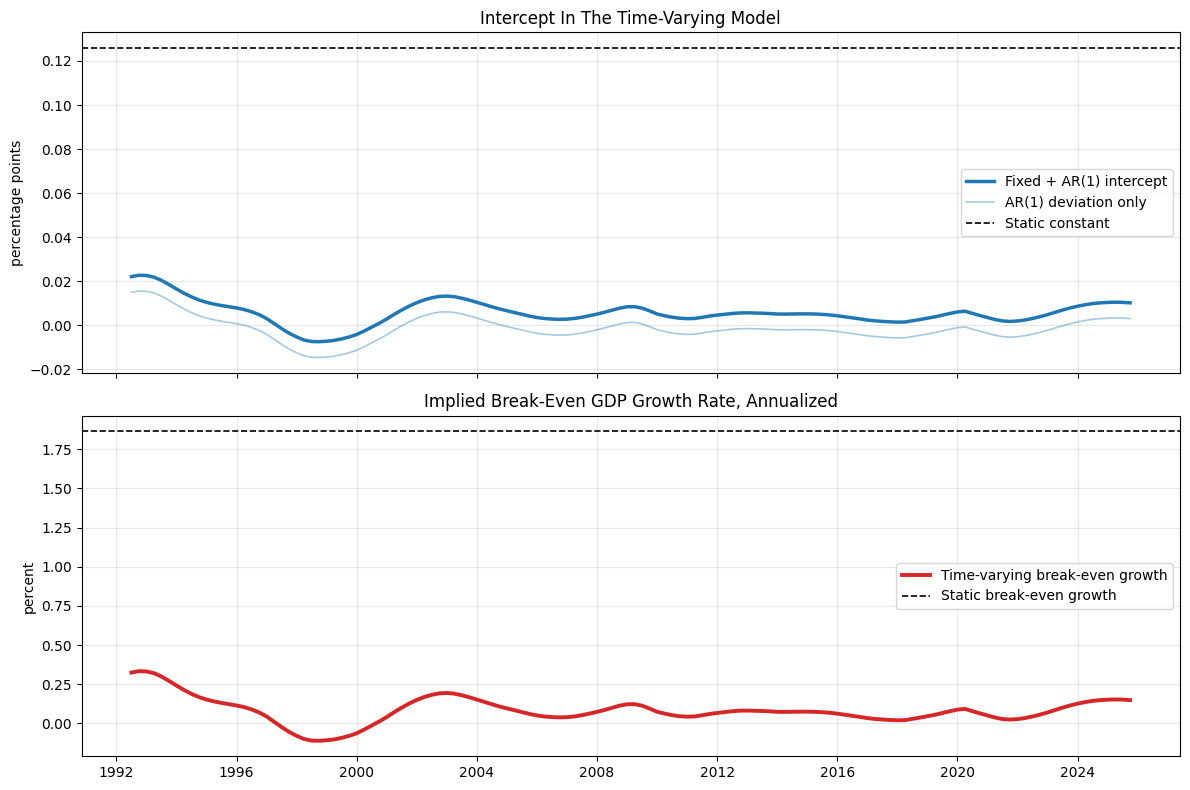

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(results_df['date'], results_df['intercept_total_t'], color='tab:blue', linewidth=2.5, label='Fixed + AR(1) intercept')
axes[0].plot(results_df['date'], results_df['c_t'], color='tab:blue', linewidth=1.2, alpha=0.4, label='AR(1) deviation only')
axes[0].axhline(ols_start.params['const'], color='black', linestyle='--', linewidth=1.2, label='Static constant')
axes[0].set_title('Intercept In The Time-Varying Model')
axes[0].set_ylabel('percentage points')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(results_df['date'], results_df['break_even_growth_annualized_pct'], color='tab:red', linewidth=2.8, label='Time-varying break-even growth')
axes[1].axhline(results_df['static_break_even_annualized_pct'].iloc[0], color='black', linestyle='--', linewidth=1.2, label='Static break-even growth')
axes[1].set_title('Implied Break-Even GDP Growth Rate, Annualized')
axes[1].set_ylabel('percent')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Save Results

In [10]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(OUTPUT_PATH, index=False)
OUTPUT_PATH

PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/outputs/time_varying_break_even_estimates.csv')

## Anchored Random-Walk Reference

For the random-walk intercept specification, the level of the latent state is not identified. A constant shift in the entire smoothed state path is equivalent to choosing a different initial state level. Here we reconstruct the random-walk model and anchor its initial implied break-even growth to the static OLS break-even rate.

In [11]:
rw_source = ModelSource.from_lists(
    transition_variables=[('', 'c_rw', ())],
    measurement_variables=[('', 'U_obs_rw', ())],
    exogenous_variables=[('', 'Y0_rw', ()), ('', 'Y1_rw', ()), ('', 'Y2_rw', ()), ('', 'D2020Q2_rw', ()), ('', 'D2020Q3_rw', ())],
    parameters=[('', 'b0_rw', ()), ('', 'b1_rw', ()), ('', 'b2_rw', ()), ('', 'g2_rw', ()), ('', 'g3_rw', ())],
    unanticipated_shocks=[('', 'eta_rw', ())],
    measurement_shocks=[('', 'eps_rw', ())],
    transition_equations=[('', ('c_rw = c_rw[-1] + eta_rw', 'c_rw = c_rw'), ())],
    measurement_equations=[('', ('U_obs_rw = c_rw + b0_rw*Y0_rw + b1_rw*Y1_rw + b2_rw*Y2_rw + g2_rw*D2020Q2_rw + g3_rw*D2020Q3_rw + eps_rw', 'U_obs_rw = c_rw + b0_rw*Y0_rw + b1_rw*Y1_rw + b2_rw*Y2_rw + g2_rw*D2020Q2_rw + g3_rw*D2020Q3_rw'), ())],
)

input_db_rw = ir.Databox.from_dict({
    'U_obs_rw': ir.Series.from_start_and_array(start_period, state_df['U'].to_numpy()),
    'Y0_rw': ir.Series.from_start_and_array(start_period, state_df['Y'].to_numpy()),
    'Y1_rw': ir.Series.from_start_and_array(start_period, state_df['Y_lag1'].to_numpy()),
    'Y2_rw': ir.Series.from_start_and_array(start_period, state_df['Y_lag2'].to_numpy()),
    'D2020Q2_rw': ir.Series.from_start_and_array(start_period, state_df['d2020q2'].to_numpy()),
    'D2020Q3_rw': ir.Series.from_start_and_array(start_period, state_df['d2020q3'].to_numpy()),
})

def build_rw_model(theta):
    b0_rw, b1_rw, b2_rw, g2_rw, g3_rw, log_std_eps_rw = theta
    model = ir.Model.from_source(rw_source, linear=True, flat=True)
    model.assign(
        c_rw=0.0,
        U_obs_rw=0.0,
        Y0_rw=0.0,
        Y1_rw=0.0,
        Y2_rw=0.0,
        D2020Q2_rw=0.0,
        D2020Q3_rw=0.0,
        b0_rw=float(b0_rw),
        b1_rw=float(b1_rw),
        b2_rw=float(b2_rw),
        g2_rw=float(g2_rw),
        g3_rw=float(g3_rw),
        std_eta_rw=float(std_eta_fixed),
        std_eps_rw=float(np.exp(log_std_eps_rw)),
    )
    model.steady(linear=True, flat=True)
    model.solve(linear=True, flat=True)
    return model

def neg_log_likelihood_rw(theta):
    try:
        model = build_rw_model(theta)
        _, info = model.kalman_filter(input_db_rw, span, deviation=False, return_=('smooth',), return_info=True)
        return float(info['neg_log_likelihood'])
    except Exception:
        return 1e9

rw_theta0 = np.array([
    ols_start.params['Y'],
    ols_start.params['Y_lag1'],
    ols_start.params['Y_lag2'],
    ols_start.params['d2020q2'],
    ols_start.params['d2020q3'],
    np.log(float(ols_start.resid.std(ddof=1))),
])

rw_bounds = [
    (-1.0, 1.0),
    (-1.0, 1.0),
    (-1.0, 1.0),
    (-2.0, 2.0),
    (-2.0, 2.0),
    (-8.0, 1.0),
]

rw_opt = minimize(
    neg_log_likelihood_rw,
    rw_theta0,
    method='L-BFGS-B',
    bounds=rw_bounds,
    options={'maxiter': 200},
)

rw_theta_hat = rw_opt.x
rw_model = build_rw_model(rw_theta_hat)
rw_output, rw_info = rw_model.kalman_filter(input_db_rw, span, deviation=False, return_=('smooth',), return_info=True)

b0_rw_hat, b1_rw_hat, b2_rw_hat, g2_rw_hat, g3_rw_hat, log_std_eps_rw_hat = rw_theta_hat
sum_beta_rw_hat = b0_rw_hat + b1_rw_hat + b2_rw_hat
c_rw_raw = rw_output['smooth_med']['c_rw'].get_data_from_until(span).flatten()

static_break_even_qoq = -ols_start.params['const'] / (ols_start.params['Y'] + ols_start.params['Y_lag1'] + ols_start.params['Y_lag2'])
target_c0 = -static_break_even_qoq * sum_beta_rw_hat
rw_shift = target_c0 - c_rw_raw[0]
c_rw_anchored = c_rw_raw + rw_shift
rw_break_even_qoq = -c_rw_anchored / sum_beta_rw_hat
rw_break_even_annualized = ((1 + rw_break_even_qoq / 100) ** 4 - 1) * 100

rw_compare = pd.DataFrame({
    'parameter': ['sum_beta_rw', 'std_eta_fixed', 'std_eps_rw', 'raw_c0', 'target_c0', 'rw_shift', 'static_break_even_qoq'],
    'estimate': [
        sum_beta_rw_hat,
        std_eta_fixed,
        float(np.exp(log_std_eps_rw_hat)),
        c_rw_raw[0],
        target_c0,
        rw_shift,
        static_break_even_qoq,
    ],
})
rw_compare

,parameter,estimate
0,sum_beta_rw,-0.271936
1,std_eta_fixed,0.007876
2,std_eps_rw,0.211191
3,raw_c0,0.054813
4,target_c0,0.125988
5,rw_shift,0.071174
6,static_break_even_qoq,0.463299


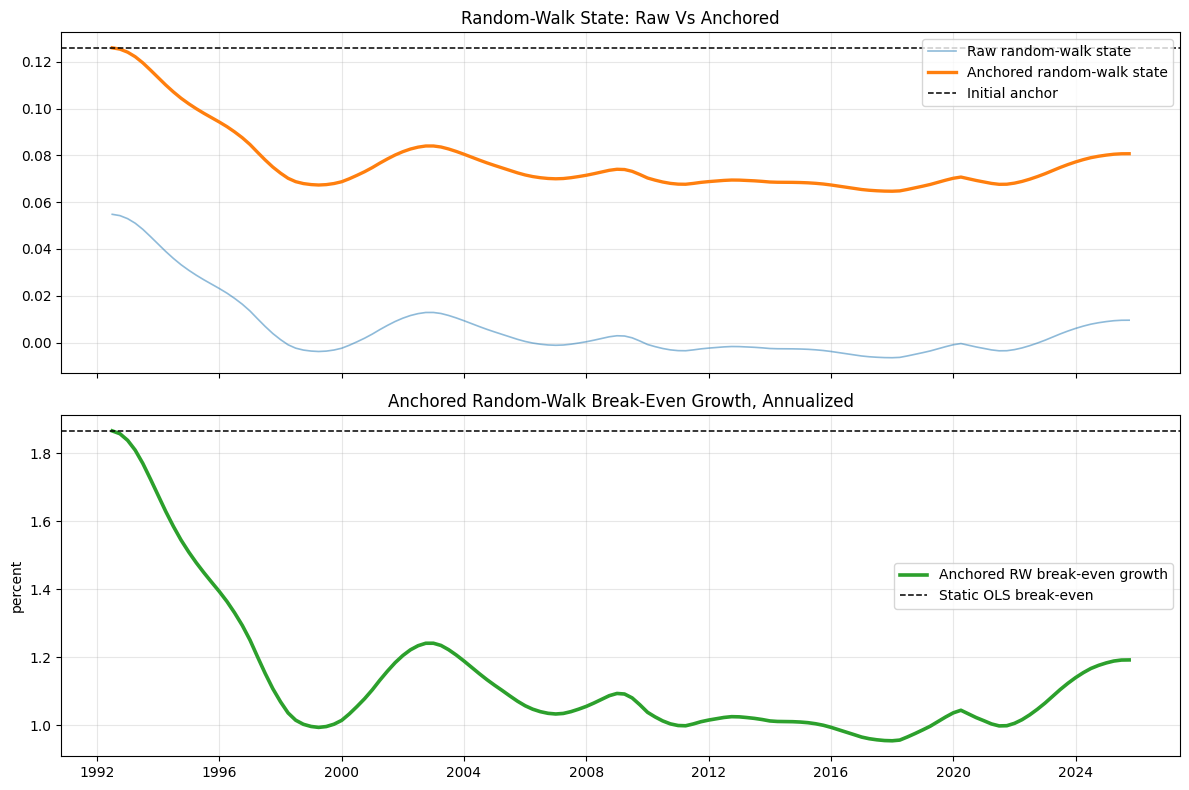

In [12]:
rw_results = pd.DataFrame({
    'date': state_df['date'],
    'c_rw_raw': c_rw_raw,
    'c_rw_anchored': c_rw_anchored,
    'rw_break_even_qoq_pct': rw_break_even_qoq,
    'rw_break_even_annualized_pct': rw_break_even_annualized,
    'static_break_even_qoq_pct': static_break_even_qoq,
    'static_break_even_annualized_pct': ((1 + static_break_even_qoq / 100) ** 4 - 1) * 100,
})

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(rw_results['date'], rw_results['c_rw_raw'], linewidth=1.2, alpha=0.5, label='Raw random-walk state')
axes[0].plot(rw_results['date'], rw_results['c_rw_anchored'], linewidth=2.4, label='Anchored random-walk state')
axes[0].axhline(target_c0, color='black', linestyle='--', linewidth=1.1, label='Initial anchor')
axes[0].set_title('Random-Walk State: Raw Vs Anchored')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rw_results['date'], rw_results['rw_break_even_annualized_pct'], linewidth=2.6, color='tab:green', label='Anchored RW break-even growth')
axes[1].axhline(rw_results['static_break_even_annualized_pct'].iloc[0], color='black', linestyle='--', linewidth=1.1, label='Static OLS break-even')
axes[1].set_title('Anchored Random-Walk Break-Even Growth, Annualized')
axes[1].set_ylabel('percent')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Random Walk Plus Fixed OLS Constant

This version keeps the random-walk intercept deviation, but fixes the constant term to the static OLS estimate. That directly anchors the level of the implied break-even growth rate to the static benchmark while still allowing time variation through the latent state.

In [13]:
alpha_fixed = float(ols_start.params['const'])

rw_alpha_source = ModelSource.from_lists(
    transition_variables=[('', 'c_alpha', ())],
    measurement_variables=[('', 'U_obs_alpha', ())],
    exogenous_variables=[('', 'Y0_alpha', ()), ('', 'Y1_alpha', ()), ('', 'Y2_alpha', ()), ('', 'D2020Q2_alpha', ()), ('', 'D2020Q3_alpha', ())],
    parameters=[('', 'b0_alpha', ()), ('', 'b1_alpha', ()), ('', 'b2_alpha', ()), ('', 'g2_alpha', ()), ('', 'g3_alpha', ())],
    unanticipated_shocks=[('', 'eta_alpha', ())],
    measurement_shocks=[('', 'eps_alpha', ())],
    transition_equations=[('', ('c_alpha = c_alpha[-1] + eta_alpha', 'c_alpha = c_alpha'), ())],
    measurement_equations=[('', ('U_obs_alpha = 0.125381560816419 + c_alpha + b0_alpha*Y0_alpha + b1_alpha*Y1_alpha + b2_alpha*Y2_alpha + g2_alpha*D2020Q2_alpha + g3_alpha*D2020Q3_alpha + eps_alpha', 'U_obs_alpha = 0.125381560816419 + c_alpha + b0_alpha*Y0_alpha + b1_alpha*Y1_alpha + b2_alpha*Y2_alpha + g2_alpha*D2020Q2_alpha + g3_alpha*D2020Q3_alpha'), ())],
)

input_db_alpha = ir.Databox.from_dict({
    'U_obs_alpha': ir.Series.from_start_and_array(start_period, state_df['U'].to_numpy()),
    'Y0_alpha': ir.Series.from_start_and_array(start_period, state_df['Y'].to_numpy()),
    'Y1_alpha': ir.Series.from_start_and_array(start_period, state_df['Y_lag1'].to_numpy()),
    'Y2_alpha': ir.Series.from_start_and_array(start_period, state_df['Y_lag2'].to_numpy()),
    'D2020Q2_alpha': ir.Series.from_start_and_array(start_period, state_df['d2020q2'].to_numpy()),
    'D2020Q3_alpha': ir.Series.from_start_and_array(start_period, state_df['d2020q3'].to_numpy()),
})

def build_rw_alpha_model(theta):
    b0_alpha, b1_alpha, b2_alpha, g2_alpha, g3_alpha, log_std_eps_alpha = theta
    model = ir.Model.from_source(rw_alpha_source, linear=True, flat=True)
    model.assign(
        c_alpha=0.0,
        U_obs_alpha=0.0,
        Y0_alpha=0.0,
        Y1_alpha=0.0,
        Y2_alpha=0.0,
        D2020Q2_alpha=0.0,
        D2020Q3_alpha=0.0,
        b0_alpha=float(b0_alpha),
        b1_alpha=float(b1_alpha),
        b2_alpha=float(b2_alpha),
        g2_alpha=float(g2_alpha),
        g3_alpha=float(g3_alpha),
        std_eta_alpha=float(std_eta_fixed),
        std_eps_alpha=float(np.exp(log_std_eps_alpha)),
    )
    model.steady(linear=True, flat=True)
    model.solve(linear=True, flat=True)
    return model

def neg_log_likelihood_rw_alpha(theta):
    try:
        model = build_rw_alpha_model(theta)
        _, info = model.kalman_filter(input_db_alpha, span, deviation=False, return_=('smooth',), return_info=True)
        return float(info['neg_log_likelihood'])
    except Exception:
        return 1e9

rw_alpha_theta0 = np.array([
    ols_start.params['Y'],
    ols_start.params['Y_lag1'],
    ols_start.params['Y_lag2'],
    ols_start.params['d2020q2'],
    ols_start.params['d2020q3'],
    np.log(float(ols_start.resid.std(ddof=1))),
])

rw_alpha_opt = minimize(
    neg_log_likelihood_rw_alpha,
    rw_alpha_theta0,
    method='L-BFGS-B',
    bounds=[(-1, 1), (-1, 1), (-1, 1), (-2, 2), (-2, 2), (-8, 1)],
    options={'maxiter': 200},
)

rw_alpha_theta_hat = rw_alpha_opt.x
rw_alpha_model = build_rw_alpha_model(rw_alpha_theta_hat)
rw_alpha_output, rw_alpha_info = rw_alpha_model.kalman_filter(
    input_db_alpha,
    span,
    deviation=False,
    return_=('smooth',),
    return_info=True,
)

b0_alpha_hat, b1_alpha_hat, b2_alpha_hat, g2_alpha_hat, g3_alpha_hat, log_std_eps_alpha_hat = rw_alpha_theta_hat
sum_beta_alpha_hat = b0_alpha_hat + b1_alpha_hat + b2_alpha_hat
c_alpha = rw_alpha_output['smooth_med']['c_alpha'].get_data_from_until(span).flatten()

static_break_even_annualized_local = ((1 + static_break_even_qoq / 100) ** 4 - 1) * 100
rw_alpha_results = state_df.loc[:, ['date', 'U', 'Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']].copy()
rw_alpha_results['alpha_fixed'] = alpha_fixed
rw_alpha_results['c_alpha'] = c_alpha
rw_alpha_results['intercept_total'] = alpha_fixed + c_alpha
rw_alpha_results['break_even_growth_qoq_pct'] = -rw_alpha_results['intercept_total'] / sum_beta_alpha_hat
rw_alpha_results['break_even_growth_annualized_pct'] = ((1 + rw_alpha_results['break_even_growth_qoq_pct'] / 100) ** 4 - 1) * 100
rw_alpha_results['static_break_even_qoq_pct'] = static_break_even_qoq
rw_alpha_results['static_break_even_annualized_pct'] = static_break_even_annualized_local

rw_alpha_summary = pd.DataFrame({
    'parameter': ['alpha_fixed', 'sum_beta_alpha', 'std_eta_fixed', 'std_eps_alpha', 'mean_break_even_qoq', 'mean_break_even_annualized'],
    'estimate': [
        alpha_fixed,
        sum_beta_alpha_hat,
        std_eta_fixed,
        float(np.exp(log_std_eps_alpha_hat)),
        rw_alpha_results['break_even_growth_qoq_pct'].mean(),
        rw_alpha_results['break_even_growth_annualized_pct'].mean(),
    ],
})
rw_alpha_summary

,parameter,estimate
0,alpha_fixed,0.125988
1,sum_beta_alpha,-0.271936
2,std_eta_fixed,0.007876
3,std_eps_alpha,0.211191
4,mean_break_even_qoq,0.022755
5,mean_break_even_annualized,0.091206


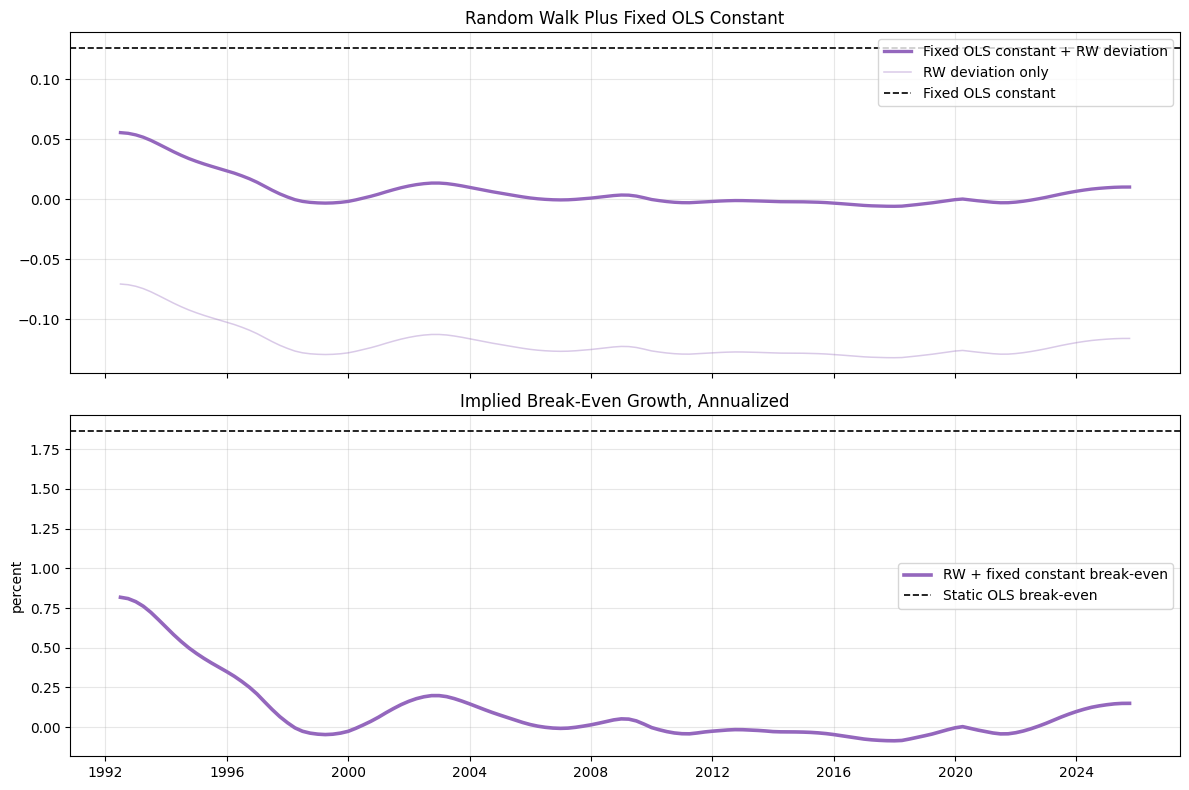

In [14]:
rw_alpha_results[['c_alpha', 'intercept_total', 'break_even_growth_qoq_pct', 'break_even_growth_annualized_pct']].describe().T

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(rw_alpha_results['date'], rw_alpha_results['intercept_total'], color='tab:purple', linewidth=2.4, label='Fixed OLS constant + RW deviation')
axes[0].plot(rw_alpha_results['date'], rw_alpha_results['c_alpha'], color='tab:purple', alpha=0.35, linewidth=1.1, label='RW deviation only')
axes[0].axhline(alpha_fixed, color='black', linestyle='--', linewidth=1.2, label='Fixed OLS constant')
axes[0].set_title('Random Walk Plus Fixed OLS Constant')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rw_alpha_results['date'], rw_alpha_results['break_even_growth_annualized_pct'], color='tab:purple', linewidth=2.6, label='RW + fixed constant break-even')
axes[1].axhline(static_break_even_annualized_local, color='black', linestyle='--', linewidth=1.2, label='Static OLS break-even')
axes[1].set_title('Implied Break-Even Growth, Annualized')
axes[1].set_ylabel('percent')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()